# Distributed Dynamic IR-Drop Decomposition Analysis

This notebook performs dynamic IR-drop analysis on a multi-tile PDN netlist using the
**distributed DDM (Domain Decomposition Method) solver** with a Ray compute backend.

The distributed solver decomposes the power grid into tiles, each solved independently,
coupled through a Schur complement interface system. This enables scaling to large designs
that exceed the memory or compute capacity of a single-node flat solver.

## Analysis Flow

1. Load pre-parsed distributed tile data and create the distributed model with Ray workers
2. Run transient RC simulation to identify worst-case instances (highest peak IR-drop)
3. For each worst instance, run **adjoint sensitivity analysis** to decompose IR-drop:
   - **Static adjoint**: Uses steady-state G^{-1} sensitivity (fast, single solve)
   - **Dynamic adjoint**: Backward sweep through RC memory (captures time-varying effects)
4. Visualize and compare the static vs dynamic attribution results

Unlike the flat notebook which uses near/far spatial window decomposition via multi-RHS
transient solves, this notebook uses adjoint sensitivity analysis -- the superior method
for identifying individual aggressor contributions to a victim's IR-drop.

## Setup and Imports

In [1]:
import sys
import os
import time as time_module
import logging
from pathlib import Path
from typing import Any, Dict, List, Optional, Set, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Change to project root so TileConfig relative paths resolve correctly
os.chdir(Path(__file__).parent.parent if '__file__' in dir() else Path('..'))

# Import distributed solver modules
from distributed import (
    load_distributed_partitions,
    create_distributed_model,
    DistributedDDMSolver,
)
from analysis.adjoint_sensitivity import AdjointAttribution, AggressorContribution

# Enable logging so solver progress messages are visible
logging.basicConfig(
    level=logging.INFO,
    format='%(message)s',
    force=True,
)

print(f"Working directory: {os.getcwd()}")
print("Imports successful!")

Working directory: /wv/bwdev1/patrasej/dev/sigma_dvd/prototype
Imports successful!


## Configuration

Set the analysis parameters here:

In [ ]:
# ==========================================
# CONFIGURATION - Modify these parameters
# ==========================================

# Netlist path (pre-parsed distributed pkl directory)
NETLIST_DIR = Path('./netlist/netlist_sampled')
PKL_DIR = NETLIST_DIR / 'distributed_pkl'

# Time parameters
T_START = 0.0           # Start time (seconds)
T_END = 1e-9            # End time (seconds) - 1 ns
DT = 0.01e-9            # Time step (seconds) - 10 ps

# Analysis parameters
TOP_K = 2               # Number of worst instances to analyze
WINDOW_PERCENT = 10.0   # Window size as percentage of design (for spatial separation)
INTEGRATION_METHOD = 'be'  # 'trap' (Trapezoidal) or 'be' (Backward Euler)

# Adjoint analysis parameters
ADJOINT_TOP_K = 10          # Number of top aggressors to report per victim
ADJOINT_MEMORY_WINDOW = 20  # Number of time steps to look back in dynamic adjoint

# Verbose output
VERBOSE = True

print("Configuration:")
print(f"  PKL dir: {PKL_DIR}")
print(f"  Time: {T_START*1e9:.2f} ns to {T_END*1e9:.2f} ns, dt={DT*1e9:.3f} ns")
print(f"  Top-K instances: {TOP_K}")
print(f"  Window: {WINDOW_PERCENT}%")
print(f"  Integration: {INTEGRATION_METHOD}")
print(f"  Adjoint Top-K: {ADJOINT_TOP_K}")
print(f"  Adjoint memory window: {ADJOINT_MEMORY_WINDOW} steps")

Configuration:
  PKL dir: /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled/distributed_pkl
  Time: 0.00 ns to 1.00 ns, dt=0.010 ns
  Top-K instances: 2
  Window: 10.0%
  Integration: be
  Adjoint Top-K: 10
  Adjoint memory window: 20 steps


## Helper Functions

In [3]:
from distributed.tile_parsing import _parse_node_xy as parse_node_coordinates


def extract_instance_locations_from_peaks(
    peak_data: Dict[str, Tuple[float, float]],
) -> Tuple[Dict[str, Tuple[float, float]], Tuple[float, float, float, float]]:
    """Extract (x, y) for each node from peak data using node name parsing.

    The distributed solver does not expose a flat graph with instance source
    objects, so we extract coordinates from the node names directly.

    Args:
        peak_data: Dict mapping node -> (peak_drop, peak_time) from as_flat().

    Returns:
        Tuple of:
        - node_coords: Dict mapping node name to (x, y) tuple
        - grid_bounds: (x_min, x_max, y_min, y_max) bounding box
    """
    node_coords: Dict[str, Tuple[float, float]] = {}

    for node in peak_data:
        x, y = parse_node_coordinates(node)
        if x is not None and y is not None:
            node_coords[node] = (float(x), float(y))

    # Compute grid bounds
    if node_coords:
        xs = [c[0] for c in node_coords.values()]
        ys = [c[1] for c in node_coords.values()]
        grid_bounds = (min(xs), max(xs), min(ys), max(ys))
    else:
        grid_bounds = (0.0, 1.0, 0.0, 1.0)

    return node_coords, grid_bounds


def find_worst_nodes_separated(
    peak_data: Dict[str, Tuple[float, float]],
    node_coords: Dict[str, Tuple[float, float]],
    grid_bounds: Tuple[float, float, float, float],
    top_k: int,
    window_percent: float = 5.0,
) -> List[Tuple[str, float, float, float, float]]:
    """Find top-K worst nodes with spatial separation.

    Uses greedy selection: picks worst node, then next worst whose
    window doesn't overlap with any already-selected window.

    Args:
        peak_data: Dict mapping node -> (peak_drop, peak_time).
        node_coords: Dict mapping node -> (x, y).
        grid_bounds: (x_min, x_max, y_min, y_max) bounding box.
        top_k: Number of worst nodes to select.
        window_percent: Window size as percentage of grid extent.

    Returns:
        List of (node, x, y, peak_drop, peak_time) tuples.
    """
    x_min_g, x_max_g, y_min_g, y_max_g = grid_bounds
    w = (x_max_g - x_min_g) * window_percent / 100.0
    h = (y_max_g - y_min_g) * window_percent / 100.0

    # Build candidates: (node, x, y, drop, time)
    candidates = []
    for node, (drop, t) in peak_data.items():
        if node in node_coords:
            x, y = node_coords[node]
            candidates.append((node, x, y, drop, t))

    # Sort by IR-drop descending
    candidates.sort(key=lambda c: c[3], reverse=True)

    selected = []
    selected_windows = []

    for node, x, y, drop, t in candidates:
        if len(selected) >= top_k:
            break

        win = (x - w / 2, x + w / 2, y - h / 2, y + h / 2)
        overlaps = any(
            not (win[1] < sw[0] or sw[1] < win[0] or win[3] < sw[2] or sw[3] < win[2])
            for sw in selected_windows
        )

        if not overlaps:
            selected.append((node, x, y, drop, t))
            selected_windows.append(win)

    return selected


print("Helper functions defined.")

Helper functions defined.


## Load Distributed Model

Load the pre-parsed tile data and create the distributed model with Ray workers.
Each tile gets its own worker that holds the local block matrix system.

In [4]:
timings = {}
t0 = time_module.perf_counter()

print(f"Loading distributed partitions from: {PKL_DIR}")
bundle = load_distributed_partitions(str(PKL_DIR))

print(f"Creating distributed model with Ray backend...")
model = create_distributed_model(bundle, backend='ray')
solver = DistributedDDMSolver(model)

timings['load_model'] = time_module.perf_counter() - t0

print(f"\nDistributed model created in {timings['load_model']:.2f}s")
print(f"  Net: {model.net_name}")
print(f"  Vdd: {model.vdd} V")
print(f"  Tiles: {model.n_tiles} ({model.tile_grid[0]}x{model.tile_grid[1]} grid)")
print(f"  Interface nodes: {len(model.interface_nodes)}")
print(f"  Pad nodes: {len(model.pad_nodes)}")

# Print per-tile summary
total_interior = sum(model.tile_interior_counts.values())
total_boundary = sum(len(bl) for bl in model.tile_boundary_nodes.values())
print(f"  Total interior nodes: {total_interior:,}")
print(f"  Total boundary nodes (with overlap): {total_boundary:,}")

Loaded metadata from /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled/distributed_pkl: 9 tiles, 1973 shared boundary nodes


Loading distributed partitions from: /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled/distributed_pkl
Creating distributed model with Ray backend...


/home/patrasej/workspace_dev2/local/miniconda3/envs/pyspice/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-28 12:46:02,426	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-28 12:46:08,770	INFO worker.py:2013 -- Started a local Ray instance.
/home/patrasej/workspace_dev2/local/miniconda3/envs/pyspice/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
Interface: 1996 nodes (1973 boundary + 27 die attachment)
Model created i


Distributed model created in 11.68s
  Net: VDD_XLV
  Vdd: 0.66 V
  Tiles: 9 (3x3 grid)
  Interface nodes: 1996
  Pad nodes: 1
  Total interior nodes: 133,584
  Total boundary nodes (with overlap): 3,957


## Initial Transient Solve

Run the full distributed transient simulation to identify the worst-case instances.
The solver uses:
1. **Preprocessing**: Vectorize and optionally smooth current sources on each tile worker
2. **DC factorization**: Factor G matrices and assemble Schur complement interface
3. **Transient factorization**: Factor A = G + C_coeff * C matrices
4. **Time stepping**: Implicit integration (Backward Euler or Trapezoidal) with distributed
   reduce-scatter at each step

In [ ]:
# Step 1: Preprocess current sources (vectorize, no smoothing to match flat solver)
print("Preprocessing current sources...")
t0 = time_module.perf_counter()
smoothed = solver.preprocess_sources(
    time_step=DT, t_start=T_START, t_end=T_END, smooth=False, verbose=VERBOSE,
)
timings['preprocess'] = time_module.perf_counter() - t0
print(f"  Done in {timings['preprocess']:.2f}s")

# Step 2: DC factorization (needed for transient IC)
print("\nFactoring DC system...")
t0 = time_module.perf_counter()
dc_ctx = solver.prepare(verbose=VERBOSE)
timings['prepare_dc'] = time_module.perf_counter() - t0
print(f"  Done in {timings['prepare_dc']:.2f}s")

# Step 3: Transient factorization
print(f"\nFactoring transient system (method={INTEGRATION_METHOD}, dt={DT*1e12:.1f}ps)...")
t0 = time_module.perf_counter()
trans_ctx = solver.prepare_transient(
    dt=DT, method=INTEGRATION_METHOD, verbose=VERBOSE,
)
timings['prepare_transient'] = time_module.perf_counter() - t0
print(f"  Done in {timings['prepare_transient']:.2f}s")

# Step 4: Transient solve (dc_ctx provides initial condition)
print(f"\nRunning transient solve ({T_START*1e9:.1f} ns to {T_END*1e9:.1f} ns)...")
t0 = time_module.perf_counter()
trans_result = solver.solve_transient(
    context=trans_ctx,
    dc_context=dc_ctx,
    t_start=T_START,
    t_end=T_END,
    smoothed_sources=smoothed,
    n_worst_nodes=TOP_K * 5,
    verbose=VERBOSE,
)
timings['transient_solve'] = time_module.perf_counter() - t0
print(f"  Done in {timings['transient_solve']:.2f}s")
print(f"  Peak IR-drop: {trans_result.peak_ir_drop * 1000:.3f} mV")
print(f"  Peak time: {trans_result.peak_ir_drop_time * 1e9:.3f} ns")

Preprocessing current sources...


VCS init: 59149 total sources across 9 tiles (9 from cache)
  init_vcs: 0.0270s
  smooth_sources: 0.4432s


  Done in 0.47s

Factoring DC system...


=== Distributed DDM Prepare Statistics ===
Tiles: 9
  Interior nodes:  13,453 / 14,843 / 15,616  (min/mean/max)
  Port nodes:      178 / 440 / 658
  G_ii nnz:        54,467 / 60,012 / 63,470
  G_ii memory:     758.0 KB / 846.6 KB / 883.5 KB  (total: 7.4 MB)
  Schur memory:    247.5 KB / 1.7 MB / 3.3 MB  (total: 15.6 MB)
  Factor time:     0.044s / 0.063s / 0.080s
  Factor backend:  cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  Factor + Schur wall time: 0.128s
Interface system: 2,015 unknowns, 1.0M nnz (density 24.668%), 11.5 MB
  Backend: cholmod(mode=auto, ordering=default, idx=auto)
  Factor time: 1.149s
  Islands penalized: 0
  Assemble time: 1.179s
  Detect islands time: 0.897s
=== Total Prepare: 3.354s ===


  Done in 3.38s

Factoring transient system (method=be, dt=10.0ps)...


=== Distributed DDM Prepare Transient Statistics ===
Method: be  |  dt: 10.0 ps  |  C_coeff: 0.1000
Tiles: 9
  A_ii nnz:         54,467 / 60,012 / 63,470  (min/mean/max)
  A_pp nnz:         180 / 604 / 1,144
  Total cap:        13581 fF / 17678 fF / 19399 fF  (total: 159098 fF)
  Schur memory:     247.5 KB / 1.7 MB / 3.3 MB  (total: 15.6 MB)
  Factor time:      0.026s / 0.064s / 0.092s
  Factor backend:   cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  Factor + Schur wall time: 0.192s
Transient interface: 2,015 unknowns, 1.0M nnz (density 24.659%), 11.5 MB
  Backend: cholmod(mode=auto, ordering=default, idx=auto)
  Factor time: 0.931s
  Has capacitance: True
  Package C_uu nnz: 0  |  Package G_uu nnz: 108
  Assemble time: 2.154s
=== Total Prepare: 3.277s ===


Matrix factorization (cholmod(mode=auto, ordering=default, idx=auto)): CSC conversion 10.90 ms, factorization 878.36 ms
  Done in 3.29s

Running transient solve (0.0 ns to 1.0 ns)...


Step 1/100 (t=1.000e-11 s): max_drop=0.0009 V, total_I=13.18 mA
Step 11/100 (t=1.100e-10 s): max_drop=0.0008 V, total_I=13.18 mA
Step 21/100 (t=2.100e-10 s): max_drop=0.0008 V, total_I=13.18 mA
Step 31/100 (t=3.100e-10 s): max_drop=0.0008 V, total_I=13.18 mA
Step 41/100 (t=4.100e-10 s): max_drop=0.0116 V, total_I=35.64 mA
Step 51/100 (t=5.100e-10 s): max_drop=0.0008 V, total_I=13.20 mA
Step 61/100 (t=6.100e-10 s): max_drop=0.0008 V, total_I=13.19 mA
Step 71/100 (t=7.100e-10 s): max_drop=0.0008 V, total_I=13.19 mA
Step 81/100 (t=8.100e-10 s): max_drop=0.0008 V, total_I=13.19 mA
Step 91/100 (t=9.100e-10 s): max_drop=0.0008 V, total_I=13.19 mA
Step 100/100 (t=1.000e-09 s): max_drop=0.0011 V, total_I=13.26 mA
=== Distributed DDM Transient Solve Statistics ===
Time steps: 100  |  t: [10ps, 1ns]  |  dt: 10ps  |  method: be
DC initial condition: 0.159s
Time loop: 2.66s (100 steps, avg 0.027s/step)
  Transient RHS:     0.013s/step (per-tile: 0.003 / 0.006 / 0.012)
  Assemble + solve:  0.002s/s

  Done in 2.83s
  Peak IR-drop: 32.170 mV
  Peak time: 0.400 ns


  Collected 135,572 nodes in 0.26s
  Nodes with coordinates: 135,572
  Grid bounds: X=[989000, 2271720], Y=[1045432, 2428800]

Top-2 worst spatially-separated nodes:
Rank  Node                                    X          Y   Peak(mV)   Time(ns)
--------------------------------------------------------------------------------
1     1912400_2256000_M0                1912400    2256000     47.842      0.400
2     1467800_1843200_M0                1467800    1843200     34.717      0.400


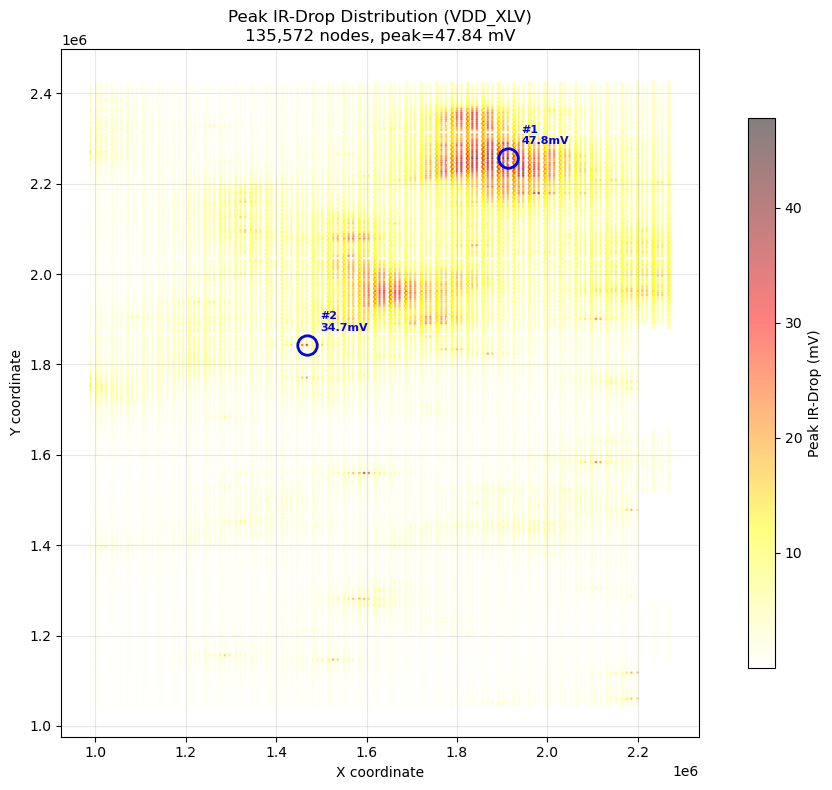

In [6]:
%matplotlib inline

# Collect peak data from workers (lazy collection)
print("Collecting peak data from workers...")
t0 = time_module.perf_counter()
peak_data = trans_result.as_flat()  # Dict[str, (peak_drop, peak_time)]
timings['collect_peaks'] = time_module.perf_counter() - t0
print(f"  Collected {len(peak_data):,} nodes in {timings['collect_peaks']:.2f}s")

# Extract node coordinates from node names
node_coords, grid_bounds = extract_instance_locations_from_peaks(peak_data)
print(f"  Nodes with coordinates: {len(node_coords):,}")
print(f"  Grid bounds: X=[{grid_bounds[0]:.0f}, {grid_bounds[1]:.0f}], "
      f"Y=[{grid_bounds[2]:.0f}, {grid_bounds[3]:.0f}]")

# Find worst spatially-separated nodes (same window % as flat notebook)
worst_instances = find_worst_nodes_separated(
    peak_data, node_coords, grid_bounds, TOP_K, window_percent=WINDOW_PERCENT,
)

print(f"\nTop-{TOP_K} worst spatially-separated nodes:")
print(f"{'Rank':<5} {'Node':<30} {'X':>10} {'Y':>10} {'Peak(mV)':>10} {'Time(ns)':>10}")
print("-" * 80)
for i, (node, x, y, drop, t) in enumerate(worst_instances, 1):
    node_short = node[:28] + '...' if len(node) > 30 else node
    print(f"{i:<5} {node_short:<30} {x:>10.0f} {y:>10.0f} {drop*1000:>10.3f} {t*1e9:>10.3f}")

# Visualize instance distribution with worst-case markers
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all nodes with coordinates as background
xs_all = [c[0] for c in node_coords.values()]
ys_all = [c[1] for c in node_coords.values()]
# Color by IR-drop
drops_all = [peak_data[n][0] * 1000 for n in node_coords]  # mV
sc = ax.scatter(xs_all, ys_all, c=drops_all, s=1, alpha=0.5, cmap='hot_r')
plt.colorbar(sc, ax=ax, label='Peak IR-Drop (mV)', shrink=0.8)

# Mark worst instances
for i, (node, x, y, drop, t) in enumerate(worst_instances, 1):
    ax.plot(x, y, 'o', markersize=14, markerfacecolor='none',
            markeredgecolor='blue', markeredgewidth=2)
    ax.annotate(f'#{i}\n{drop*1000:.1f}mV', (x, y),
                textcoords='offset points', xytext=(10, 10),
                fontsize=8, color='blue', fontweight='bold')

ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Peak IR-Drop Distribution ({model.net_name})\n'
             f'{len(node_coords):,} nodes, peak={trans_result.peak_ir_drop*1000:.2f} mV')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Adjoint Sensitivity Analysis

For each worst-case node, we identify the **top aggressor current sources** that
contribute most to its IR-drop using adjoint sensitivity.

Two complementary methods are compared:

- **Static adjoint** (`analyze_adjoint_static`): Uses the steady-state sensitivity
  matrix G^{-1}. Answers: *"If this source were always on, how much would it affect
  the victim?"* Fast (reuses DC factorization) but ignores RC time constants.

- **Dynamic adjoint** (`analyze_adjoint`): Propagates sensitivities backward through
  the RC network's memory window. Answers: *"Given the actual time-varying currents,
  which sources contributed most to the IR-drop at time T?"*

The adjoint approach is superior to the near/far spatial window decomposition because
it identifies **individual source contributions** rather than just aggregate spatial regions.

In [7]:
from dataclasses import dataclass as _dc


@_dc
class AdjointComparison:
    """Holds static and dynamic adjoint results for one victim."""
    node: str
    x: float
    y: float
    peak_drop_mV: float
    peak_time_ns: float
    static_result: AdjointAttribution
    dynamic_result: AdjointAttribution


adjoint_comparisons: List[AdjointComparison] = []

# Use a large top_k for the dynamic adjoint so we capture ALL per-node
# contributions.  The comparison tables (next cell) display only the first
# ADJOINT_TOP_K entries; the near/far decomposition cell uses all of them
# for an exact spatial partition.
_ADJOINT_ALL_K = 200_000  # larger than total nodes — effectively "all"

for rank, (node, x, y, peak_drop, peak_time) in enumerate(worst_instances, 1):
    print(f"\n{'='*70}")
    print(f"Instance #{rank}: node={node}")
    print(f"  Location: ({x:.0f}, {y:.0f})")
    print(f"  Peak IR-drop: {peak_drop*1000:.3f} mV at t={peak_time*1e9:.3f} ns")

    observation_time = peak_time

    # --- Static adjoint ---
    print(f"\n  Running static adjoint (top-{ADJOINT_TOP_K})...")
    t0 = time_module.perf_counter()
    static_attr = solver.analyze_adjoint_static(
        victim_nodes=node,
        observation_time=observation_time,
        dc_context=dc_ctx,
        top_k=ADJOINT_TOP_K,
        include_waveforms=False,
        verbose=VERBOSE,
    )
    t_static = time_module.perf_counter() - t0
    print(f"    Done in {t_static:.2f}s")
    print(f"    IR-drop at T: {static_attr.ir_drop_at_T:.3f} mV")
    print(f"    Self-contribution: {static_attr.self_contribution_mV:.3f} mV "
          f"({static_attr.self_contribution_pct:.1f}%)")
    print(f"    Attribution efficiency: {static_attr.attribution_efficiency:.4f}")

    # --- Dynamic adjoint (all contributions) ---
    print(f"\n  Running dynamic adjoint (memory_window={ADJOINT_MEMORY_WINDOW}, all sources)...")
    t0 = time_module.perf_counter()
    dynamic_attr = solver.analyze_adjoint(
        victim_nodes=node,
        observation_time=observation_time,
        trans_context=trans_ctx,
        transient_result=trans_result,
        memory_window=ADJOINT_MEMORY_WINDOW,
        top_k=_ADJOINT_ALL_K,
        include_waveforms=True,
        verbose=VERBOSE,
    )
    t_dynamic = time_module.perf_counter() - t0
    print(f"    Done in {t_dynamic:.2f}s")
    print(f"    IR-drop at T: {dynamic_attr.ir_drop_at_T:.3f} mV")
    print(f"    Self-contribution: {dynamic_attr.self_contribution_mV:.3f} mV "
          f"({dynamic_attr.self_contribution_pct:.1f}%)")
    print(f"    Attribution efficiency: {dynamic_attr.attribution_efficiency:.4f}")
    print(f"    Total aggressors returned: {len(dynamic_attr.top_aggressors)}")

    adjoint_comparisons.append(AdjointComparison(
        node=node, x=x, y=y,
        peak_drop_mV=peak_drop * 1000,
        peak_time_ns=peak_time * 1e9,
        static_result=static_attr,
        dynamic_result=dynamic_attr,
    ))

print(f"\n{'='*70}")
print(f"Adjoint analysis complete for {len(adjoint_comparisons)} instances.")


Instance #1: node=1912400_2256000_M0
  Location: (1912400, 2256000)
  Peak IR-drop: 47.842 mV at t=0.400 ns

  Running static adjoint (top-10)...


Victim '1912400_2256000_M0' found in tiles: [(2, 2)]
Tile (2, 2): victim is interior (idx=2286)
Adjoint static analysis for '1912400_2256000_M0':
  IR-drop at T: 55.277 mV
  Self contribution: 11.588 mV (21.0%)
  Top aggressor: 1902400_2256000_M0 (6.220 mV, 11.3%)
  Attribution efficiency: 1.000
  Total time: 0.618s
Victim '1912400_2256000_M0' found in tiles: [(2, 2)]
Backward sweep: 21 steps, dt=1.00e-11 s, t_start=2.00e-10 s, T=4.00e-10 s


    Done in 1.54s
    IR-drop at T: 55.277 mV
    Self-contribution: 11.588 mV (21.0%)
    Attribution efficiency: 1.0000

  Running dynamic adjoint (memory_window=20, all sources)...


Backward step 10/20 (t=3.000e-10 s)
Backward step 20/20 (t=2.000e-10 s)
Adjoint dynamic analysis for '1912400_2256000_M0':
  IR-drop at T: 47.842 mV
  Self contribution: 11.308 mV (23.6%)
  Top aggressor: 1902400_2256000_M0 (6.017 mV, 12.6%)
  Attribution efficiency: 1.000
  Total time: 78.507s
Victim '1467800_1843200_M0' found in tiles: [(1, 1)]
Tile (1, 1): victim is interior (idx=1650)


    Done in 78.84s
    IR-drop at T: 47.842 mV
    Self-contribution: 11.308 mV (23.6%)
    Attribution efficiency: 1.0000
    Total aggressors returned: 28182

Instance #2: node=1467800_1843200_M0
  Location: (1467800, 1843200)
  Peak IR-drop: 34.717 mV at t=0.400 ns

  Running static adjoint (top-10)...


Adjoint static analysis for '1467800_1843200_M0':
  IR-drop at T: 39.125 mV
  Self contribution: 32.831 mV (83.9%)
  Top aggressor: 1492000_1848000_M0 (0.250 mV, 0.6%)
  Attribution efficiency: 1.000
  Total time: 0.840s
Victim '1467800_1843200_M0' found in tiles: [(1, 1)]
Backward sweep: 21 steps, dt=1.00e-11 s, t_start=2.00e-10 s, T=4.00e-10 s


    Done in 0.86s
    IR-drop at T: 39.125 mV
    Self-contribution: 32.831 mV (83.9%)
    Attribution efficiency: 1.0000

  Running dynamic adjoint (memory_window=20, all sources)...


Backward step 10/20 (t=3.000e-10 s)
Backward step 20/20 (t=2.000e-10 s)
Adjoint dynamic analysis for '1467800_1843200_M0':
  IR-drop at T: 34.717 mV
  Self contribution: 30.704 mV (88.4%)
  Top aggressor: 1492000_1848000_M0 (0.199 mV, 0.6%)
  Attribution efficiency: 1.000
  Total time: 82.048s


    Done in 82.38s
    IR-drop at T: 34.717 mV
    Self-contribution: 30.704 mV (88.4%)
    Attribution efficiency: 1.0000
    Total aggressors returned: 28182

Adjoint analysis complete for 2 instances.


In [8]:
# Print detailed comparison tables
for comp in adjoint_comparisons:
    s = comp.static_result
    d = comp.dynamic_result

    print(f"\n{'='*90}")
    print(f"ADJOINT COMPARISON: {comp.node}")
    print(f"  Location: ({comp.x:.0f}, {comp.y:.0f})  |  Peak: {comp.peak_drop_mV:.3f} mV at {comp.peak_time_ns:.3f} ns")
    print(f"{'='*90}")

    # Summary row
    print(f"\n  {'Metric':<30} {'Static':>15} {'Dynamic':>15} {'Diff':>12}")
    print(f"  {'-'*72}")
    print(f"  {'IR-drop at T (mV)':<30} {s.ir_drop_at_T:>15.3f} {d.ir_drop_at_T:>15.3f} "
          f"{d.ir_drop_at_T - s.ir_drop_at_T:>+12.3f}")
    print(f"  {'Self-contribution (mV)':<30} {s.self_contribution_mV:>15.3f} {d.self_contribution_mV:>15.3f} "
          f"{d.self_contribution_mV - s.self_contribution_mV:>+12.3f}")
    print(f"  {'Self-contribution (%)':<30} {s.self_contribution_pct:>15.1f} {d.self_contribution_pct:>15.1f}")
    print(f"  {'Attribution efficiency':<30} {s.attribution_efficiency:>15.4f} {d.attribution_efficiency:>15.4f}")
    print(f"  {'Total attributed (mV)':<30} {s.total_attributed_ir_drop:>15.3f} {d.total_attributed_ir_drop:>15.3f}")

    # Top aggressors side by side
    print(f"\n  TOP-{ADJOINT_TOP_K} AGGRESSORS")
    print(f"  {'Rank':<5} {'Static Node':<25} {'mV':>8} {'%':>6}   {'Dynamic Node':<25} {'mV':>8} {'%':>6}")
    print(f"  {'-'*90}")

    n_rows = max(len(s.top_aggressors), len(d.top_aggressors))
    for i in range(n_rows):
        # Static column
        if i < len(s.top_aggressors):
            sa = s.top_aggressors[i]
            s_node = str(sa.node)[:23]
            s_mv = f"{sa.contribution_mV:.3f}"
            s_pct = f"{sa.contribution_pct:.1f}"
        else:
            s_node, s_mv, s_pct = "", "", ""

        # Dynamic column
        if i < len(d.top_aggressors):
            da = d.top_aggressors[i]
            d_node = str(da.node)[:23]
            d_mv = f"{da.contribution_mV:.3f}"
            d_pct = f"{da.contribution_pct:.1f}"
        else:
            d_node, d_mv, d_pct = "", "", ""

        print(f"  {i+1:<5} {s_node:<25} {s_mv:>8} {s_pct:>6}   {d_node:<25} {d_mv:>8} {d_pct:>6}")

    # Check overlap in top-K sets
    s_nodes = {a.node for a in s.top_aggressors}
    d_nodes = {a.node for a in d.top_aggressors}
    overlap = s_nodes & d_nodes
    print(f"\n  Overlap in top-{ADJOINT_TOP_K}: {len(overlap)}/{ADJOINT_TOP_K} nodes in common")


ADJOINT COMPARISON: 1912400_2256000_M0
  Location: (1912400, 2256000)  |  Peak: 47.842 mV at 0.400 ns

  Metric                                  Static         Dynamic         Diff
  ------------------------------------------------------------------------
  IR-drop at T (mV)                       55.277          47.842       -7.434
  Self-contribution (mV)                  11.588          11.308       -0.279
  Self-contribution (%)                     21.0            23.6
  Attribution efficiency                  1.0000          1.0000
  Total attributed (mV)                   55.277          47.842

  TOP-10 AGGRESSORS
  Rank  Static Node                     mV      %   Dynamic Node                    mV      %
  ------------------------------------------------------------------------------------------
  1     1902400_2256000_M0           6.220   11.3   1902400_2256000_M0           6.017   12.6
  2     1936600_2256000_M0           3.755    6.8   1936600_2256000_M0           3.581    

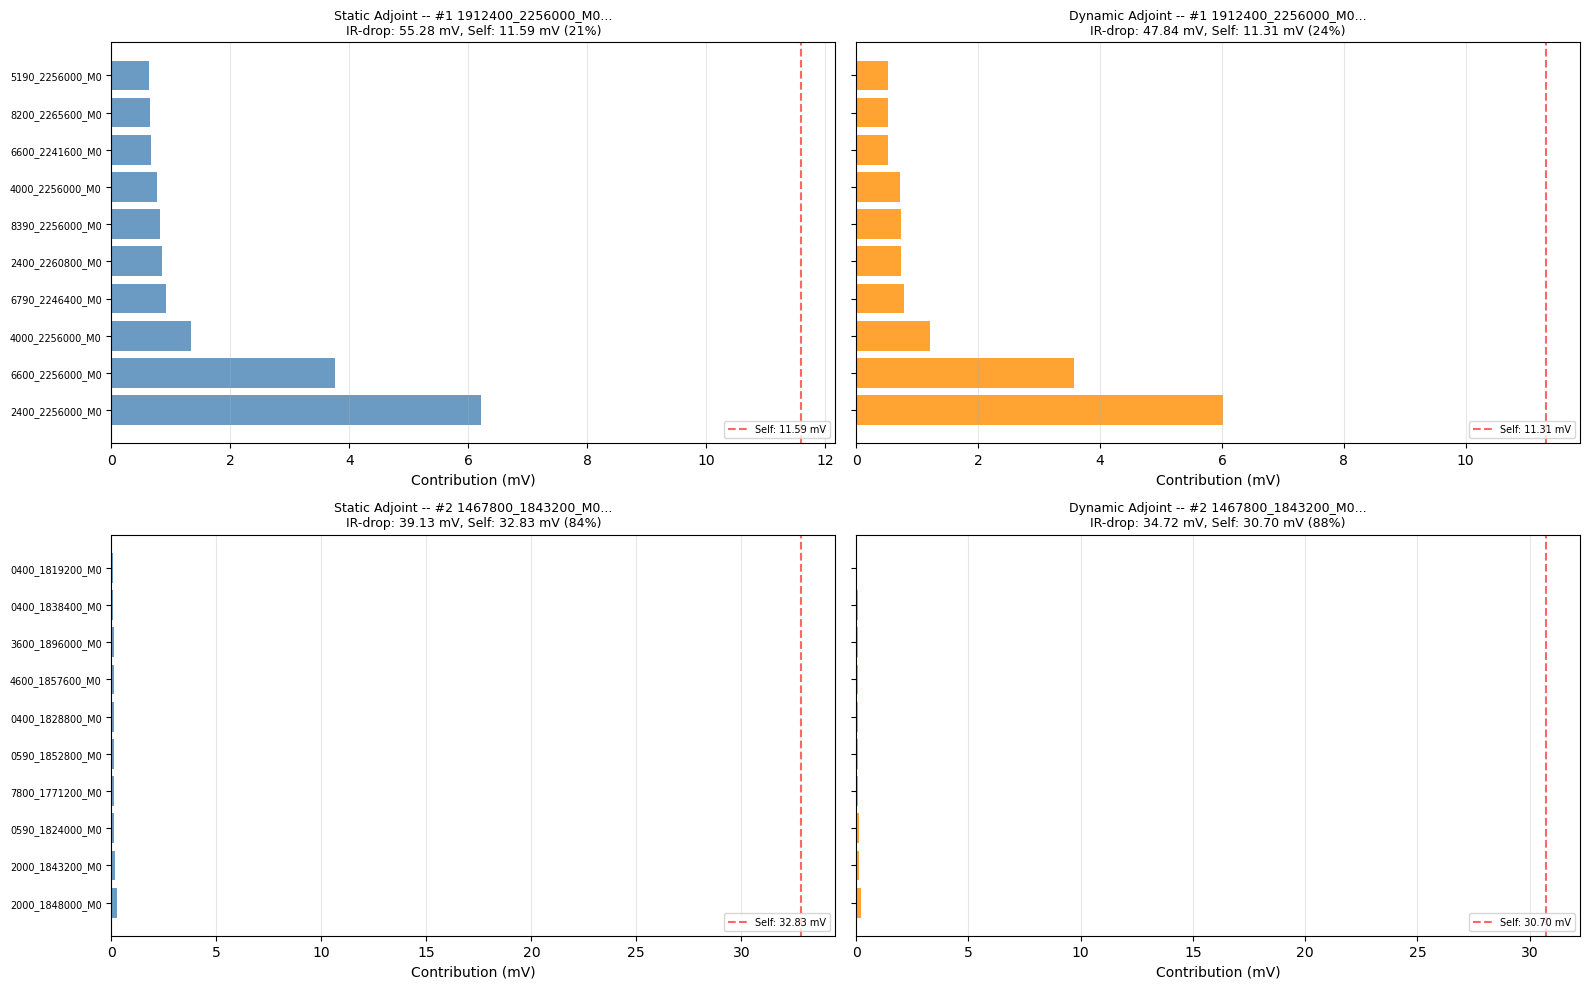

In [9]:
# Visualization: Side-by-side bar charts of top-K aggressors (static vs dynamic)
n_victims = len(adjoint_comparisons)
fig, axes = plt.subplots(n_victims, 2, figsize=(16, 5 * n_victims), sharey='row')
if n_victims == 1:
    axes = axes.reshape(1, -1)

for vi, comp in enumerate(adjoint_comparisons):
    for ci, (label, attr, color) in enumerate([
        ('Static', comp.static_result, 'steelblue'),
        ('Dynamic', comp.dynamic_result, 'darkorange'),
    ]):
        ax = axes[vi, ci]
        aggressors = attr.top_aggressors[:ADJOINT_TOP_K]
        nodes = [str(a.node)[-15:] for a in aggressors]  # last 15 chars
        contribs = [a.contribution_mV for a in aggressors]

        y_pos = np.arange(len(aggressors))
        ax.barh(y_pos, contribs, color=color, alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(nodes, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel('Contribution (mV)')
        ax.set_title(
            f'{label} Adjoint -- #{vi+1} {comp.node[:20]}...\n'
            f'IR-drop: {attr.ir_drop_at_T:.2f} mV, '
            f'Self: {attr.self_contribution_mV:.2f} mV ({attr.self_contribution_pct:.0f}%)',
            fontsize=9,
        )
        ax.grid(axis='x', alpha=0.3)

        # Add self-contribution marker
        if attr.self_contribution_mV > 0:
            ax.axvline(attr.self_contribution_mV, color='red', linestyle='--',
                       alpha=0.6, label=f'Self: {attr.self_contribution_mV:.2f} mV')
            ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

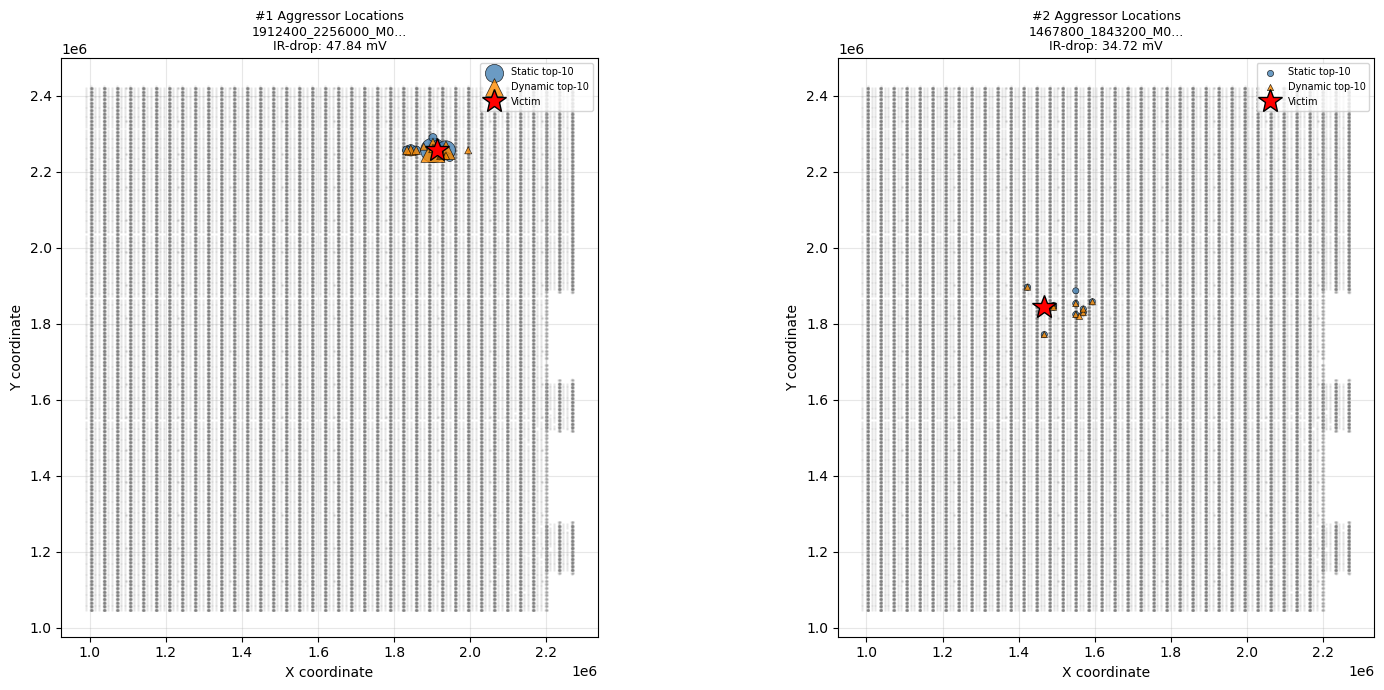

In [10]:
# Spatial map: aggressor locations for each victim
fig, axes = plt.subplots(1, n_victims, figsize=(8 * n_victims, 7))
if n_victims == 1:
    axes = [axes]

for vi, comp in enumerate(adjoint_comparisons):
    ax = axes[vi]

    # Background: all nodes in gray
    ax.scatter(xs_all, ys_all, alpha=0.1, s=1, c='gray')

    # Plot top aggressor locations for both methods
    for label, attr, marker, color in [
        ('Static', comp.static_result, 'o', 'steelblue'),
        ('Dynamic', comp.dynamic_result, '^', 'darkorange'),
    ]:
        agg_xs, agg_ys, agg_sizes = [], [], []
        for agg in attr.top_aggressors[:ADJOINT_TOP_K]:
            # Parse coordinates from the aggressor node name
            coords = parse_node_coordinates(agg.node)
            if coords[0] is not None:
                agg_xs.append(coords[0])
                agg_ys.append(coords[1])
                agg_sizes.append(max(20, abs(agg.contribution_mV) * 50))

        ax.scatter(agg_xs, agg_ys, s=agg_sizes, marker=marker, color=color,
                   edgecolors='black', linewidths=0.5, alpha=0.8,
                   label=f'{label} top-{ADJOINT_TOP_K}')

    # Mark victim
    ax.plot(comp.x, comp.y, '*', markersize=18, color='red', markeredgecolor='black',
            markeredgewidth=1, label='Victim', zorder=10)

    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_title(
        f'#{vi+1} Aggressor Locations\n{comp.node[:35]}...\n'
        f'IR-drop: {comp.peak_drop_mV:.2f} mV',
        fontsize=9,
    )
    ax.legend(loc='upper right', fontsize=7)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Near/Far Decomposition via Adjoint Attribution

For each worst-case victim, define a spatial window (same `WINDOW_PERCENT` as the flat notebook)
and partition the **adjoint-attributed contributions** into:
- **Near**: sources inside the window around the victim
- **Far**: sources outside the window

This uses the per-source contributions from the dynamic adjoint analysis. Unlike the flat
notebook's multi-RHS approach (which runs 3 separate transient solves with masked sources),
the adjoint decomposition accounts for coupling through the grid and gives exact per-source
attribution in a single backward sweep.

In [11]:
from distributed.tile_parsing import _parse_node_xy

def compute_window(cx: float, cy: float, bounds, pct: float):
    """Compute rectangular window centered at (cx, cy)."""
    x0, x1, y0, y1 = bounds
    w = (x1 - x0) * pct / 100.0
    h = (y1 - y0) * pct / 100.0
    return (max(x0, cx - w/2), min(x1, cx + w/2),
            max(y0, cy - h/2), min(y1, cy + h/2))

def decompose_near_far(attr, window, max_aggressors=None):
    """Partition adjoint contributions into near/far by spatial window.

    Args:
        attr: AdjointAttribution result (dynamic).
        window: (x_min, x_max, y_min, y_max) spatial window.
        max_aggressors: If set, only use the first N aggressors (for top-K comparison).
            If None, use ALL aggressors in attr.top_aggressors.

    Returns:
        (near_mV, far_mV, n_near_agg, n_far_agg)
    """
    x_min, x_max, y_min, y_max = window
    near_mV, far_mV = 0.0, 0.0
    n_near, n_far = 0, 0

    # Self-contribution (victim's own sources) — always "near"
    near_mV += attr.self_contribution_mV

    aggressors = attr.top_aggressors
    if max_aggressors is not None:
        aggressors = aggressors[:max_aggressors]

    for agg in aggressors:
        x, y = _parse_node_xy(agg.node)
        if x is not None and x_min <= x <= x_max and y_min <= y <= y_max:
            near_mV += agg.contribution_mV
            n_near += 1
        else:
            far_mV += agg.contribution_mV
            n_far += 1

    # If using a subset, distribute the unattributed remainder proportionally
    if max_aggressors is not None:
        top_total = attr.self_contribution_mV + sum(a.contribution_mV for a in aggressors)
        remainder = attr.total_attributed_ir_drop - top_total
        if near_mV + far_mV > 0:
            frac = near_mV / (near_mV + far_mV)
            near_mV += remainder * frac
            far_mV += remainder * (1 - frac)

    return near_mV, far_mV, n_near, n_far


# Compute near/far for each victim using ALL dynamic adjoint contributions
print(f"{'='*90}")
print(f"ADJOINT NEAR/FAR DECOMPOSITION (Window = {WINDOW_PERCENT}% of design)")
print(f"{'='*90}")
print(f"\n  Using ALL per-node contributions from dynamic adjoint (not just top-{ADJOINT_TOP_K})")

print(f"\n{'Rank':<5} {'Node':<25} {'Peak(mV)':<10} {'Near(mV)':<10} {'Far(mV)':<10} "
      f"{'Near%':<7} {'Far%':<7} {'#Near':<6} {'#Far':<6}")
print("-" * 90)

near_far_results = []
for i, comp in enumerate(adjoint_comparisons):
    window = compute_window(comp.x, comp.y, grid_bounds, WINDOW_PERCENT)
    d = comp.dynamic_result

    # Exact decomposition using ALL aggressors
    near_mV, far_mV, n_near, n_far = decompose_near_far(d, window, max_aggressors=None)
    total = near_mV + far_mV
    near_pct = 100.0 * near_mV / total if total > 0 else 0.0
    far_pct = 100.0 * far_mV / total if total > 0 else 0.0

    # Also compute top-K-only for comparison
    near_topk, far_topk, _, _ = decompose_near_far(d, window, max_aggressors=ADJOINT_TOP_K)
    total_topk = near_topk + far_topk
    near_pct_topk = 100.0 * near_topk / total_topk if total_topk > 0 else 0.0

    near_far_results.append({
        'node': comp.node, 'x': comp.x, 'y': comp.y,
        'window': window,
        'peak_mV': comp.peak_drop_mV,
        'near_mV': near_mV, 'far_mV': far_mV,
        'near_pct': near_pct, 'far_pct': far_pct,
        'n_near': n_near, 'n_far': n_far,
        'near_pct_topk': near_pct_topk,
    })

    node_short = comp.node[:23] + '..' if len(comp.node) > 25 else comp.node
    print(f"{i+1:<5} {node_short:<25} {comp.peak_drop_mV:<10.3f} {near_mV:<10.3f} "
          f"{far_mV:<10.3f} {near_pct:<7.1f} {far_pct:<7.1f} {n_near:<6} {n_far:<6}")
    print(f"      Window: [{window[0]:.0f}-{window[1]:.0f}] x [{window[2]:.0f}-{window[3]:.0f}]"
          f"  (top-{ADJOINT_TOP_K} only: Near {near_pct_topk:.1f}%)")

if near_far_results:
    avg_near = np.mean([r['near_pct'] for r in near_far_results])
    avg_far = np.mean([r['far_pct'] for r in near_far_results])
    avg_near_topk = np.mean([r['near_pct_topk'] for r in near_far_results])
    print(f"\nAll sources:  Near {avg_near:.1f}%  |  Far {avg_far:.1f}%")
    print(f"Top-{ADJOINT_TOP_K} only:  Near {avg_near_topk:.1f}%  (approximate)")

ADJOINT NEAR/FAR DECOMPOSITION (Window = 10.0% of design)

  Using ALL per-node contributions from dynamic adjoint (not just top-10)

Rank  Node                      Peak(mV)   Near(mV)   Far(mV)    Near%   Far%    #Near  #Far  
------------------------------------------------------------------------------------------
1     1912400_2256000_M0        47.842     35.177     12.666     73.5    26.5    276    27906 
      Window: [1848264-1976536] x [2186832-2325168]  (top-10 only: Near 90.8%)
2     1467800_1843200_M0        34.717     31.660     3.057      91.2    8.8     296    27886 
      Window: [1403664-1531936] x [1774032-1912368]  (top-10 only: Near 98.2%)

All sources:  Near 82.4%  |  Far 17.6%
Top-10 only:  Near 94.5%  (approximate)


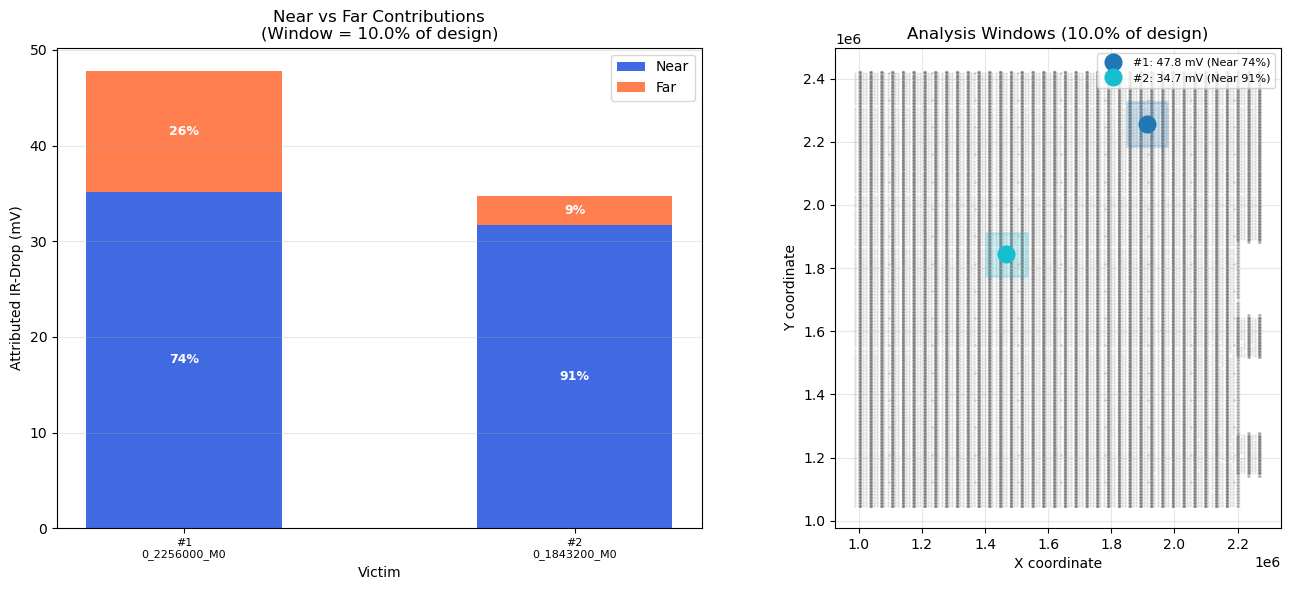

In [12]:
# Near vs Far bar chart + spatial map with windows
n_inst = len(near_far_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: stacked bar chart
ax = axes[0]
x_pos = np.arange(n_inst)
near_vals = [r['near_mV'] for r in near_far_results]
far_vals = [r['far_mV'] for r in near_far_results]
labels = [f"#{i+1}\n{r['node'][-12:]}" for i, r in enumerate(near_far_results)]

ax.bar(x_pos, near_vals, 0.5, label='Near', color='royalblue')
ax.bar(x_pos, far_vals, 0.5, bottom=near_vals, label='Far', color='coral')
for i, r in enumerate(near_far_results):
    ax.text(i, r['near_mV'] / 2, f"{r['near_pct']:.0f}%",
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if r['far_mV'] > 0.5:
        ax.text(i, r['near_mV'] + r['far_mV'] / 2, f"{r['far_pct']:.0f}%",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_xlabel('Victim')
ax.set_ylabel('Attributed IR-Drop (mV)')
ax.set_title(f'Near vs Far Contributions\n(Window = {WINDOW_PERCENT}% of design)')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: spatial map with analysis windows
ax = axes[1]
ax.scatter(xs_all, ys_all, alpha=0.1, s=1, c='gray')
colors_map = plt.cm.tab10(np.linspace(0, 1, n_inst))
for i, r in enumerate(near_far_results):
    wx_min, wx_max, wy_min, wy_max = r['window']
    rect = patches.Rectangle(
        (wx_min, wy_min), wx_max - wx_min, wy_max - wy_min,
        linewidth=2, edgecolor=colors_map[i], facecolor=colors_map[i], alpha=0.2,
    )
    ax.add_patch(rect)
    ax.plot(r['x'], r['y'], 'o', markersize=12, color=colors_map[i],
            label=f"#{i+1}: {r['peak_mV']:.1f} mV (Near {r['near_pct']:.0f}%)")

ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Analysis Windows ({WINDOW_PERCENT}% of design)')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Near/Far Transient Waveform Decomposition

The adjoint analysis above gives **per-source scalar attribution** of IR-drop.
This section complements it with **time-domain waveforms** showing how near vs far
IR-drop evolves over the simulation.

**Approach**: For each victim, define a spatial window (same `WINDOW_PERCENT` as above)
and run a separate transient solve with only the **near** current sources active
(all other sources masked to zero). By linearity of the system:

```
V_all = V_near + V_far    =>    drop_far = drop_all - drop_near
```

This requires only 1 + N_victims transient solves:
1. One all-sources transient solve (reuses existing `trans_ctx` factorization)
2. One near-only transient per victim (same factorization, different RHS)

The transient matrix A = G + C_coeff * C does not depend on currents, so the
factorization is reused. Only peak tracking is re-initialized per solve.

In [13]:
# --- Near/Far Transient Waveform Decomposition ---
#
# Step 1: Get DC result for consistent initial conditions across all solves.
# Step 2: Run all-sources transient tracking victim nodes.
# Step 3: For each victim, mask near sources, run near-only transient, compute far.

victim_nodes = [node for node, *_ in worst_instances]
n_tiles = model.n_tiles

# Step 1: DC solve to get ic_voltages (same IC for all/near solves)
print("Solving DC for initial conditions...")
t0 = time_module.perf_counter()
dc_result = solver.solve_dc(dc_ctx, verbose=False)
t_dc = time_module.perf_counter() - t0
print(f"  DC solve: {t_dc:.2f}s")

# Step 2: All-sources transient with victim waveform tracking
print(f"\nRunning all-sources transient (tracking {len(victim_nodes)} victims)...")
t0 = time_module.perf_counter()
all_trans = solver.solve_transient(
    context=trans_ctx,
    ic_voltages=dc_result,
    t_start=T_START,
    t_end=T_END,
    smoothed_sources=smoothed,
    track_nodes=victim_nodes,
    verbose=False,
)
t_all = time_module.perf_counter() - t0
print(f"  All-sources transient: {t_all:.2f}s, peak={all_trans.peak_ir_drop*1000:.3f} mV")

# Step 3: Near-only transient for each victim
waveform_decompositions = []

for rank, (node, x, y, peak_drop, peak_time) in enumerate(worst_instances, 1):
    print(f"\n--- Victim #{rank}: {node} ---")

    # Compute spatial window
    window = compute_window(x, y, grid_bounds, WINDOW_PERCENT)
    x_min, x_max, y_min, y_max = window
    print(f"  Window: [{x_min:.0f}, {x_max:.0f}] x [{y_min:.0f}, {y_max:.0f}]")

    # Build near mask on all workers
    print("  Building near mask on workers...")
    mask_args = [(x_min, x_max, y_min, y_max, True)] * n_tiles
    near_masks = model.backend.call_all(
        model.workers, 'build_node_mask_for_window', mask_args,
    )

    # Set mask on all workers
    set_args = [(m,) for m in near_masks]
    model.backend.call_all(model.workers, 'set_current_node_mask', set_args)

    # Run near-only transient
    print("  Running near-only transient...")
    t0 = time_module.perf_counter()
    near_trans = solver.solve_transient(
        context=trans_ctx,
        ic_voltages=dc_result,
        t_start=T_START,
        t_end=T_END,
        smoothed_sources=smoothed,
        track_nodes=[node],
        verbose=False,
    )
    t_near = time_module.perf_counter() - t0
    print(f"  Near-only transient: {t_near:.2f}s, peak={near_trans.peak_ir_drop*1000:.3f} mV")

    # Clear mask on all workers
    clear_args = [(None,)] * n_tiles
    model.backend.call_all(model.workers, 'set_current_node_mask', clear_args)

    # Extract waveforms
    t_array = all_trans.t_array
    all_irdrop = all_trans.tracked_ir_drop.get(node)
    near_irdrop = near_trans.tracked_ir_drop.get(node)

    if all_irdrop is not None and near_irdrop is not None:
        # Lengths may differ slightly at edges; truncate to common length
        n_common = min(len(all_irdrop), len(near_irdrop))
        all_irdrop = all_irdrop[:n_common]
        near_irdrop = near_irdrop[:n_common]
        far_irdrop = all_irdrop - near_irdrop
        t_arr_common = t_array[:n_common]

        # Peak values
        peak_all = float(np.max(all_irdrop))
        peak_near = float(np.max(near_irdrop))
        peak_idx = int(np.argmax(all_irdrop))
        near_at_peak = float(near_irdrop[peak_idx])
        far_at_peak = float(far_irdrop[peak_idx])

        waveform_decompositions.append({
            'rank': rank,
            'node': node,
            'x': x, 'y': y,
            'window': window,
            't_array': t_arr_common,
            'ir_drop_all': all_irdrop,
            'ir_drop_near': near_irdrop,
            'ir_drop_far': far_irdrop,
            'peak_all_mV': peak_all * 1000,
            'peak_near_mV': peak_near * 1000,
            'near_at_peak_mV': near_at_peak * 1000,
            'far_at_peak_mV': far_at_peak * 1000,
            'near_pct_at_peak': 100 * near_at_peak / peak_all if peak_all > 0 else 0,
            'far_pct_at_peak': 100 * far_at_peak / peak_all if peak_all > 0 else 0,
        })
        print(f"  Peak: {peak_all*1000:.3f} mV  "
              f"Near: {near_at_peak*1000:.3f} mV ({100*near_at_peak/peak_all:.1f}%)  "
              f"Far: {far_at_peak*1000:.3f} mV ({100*far_at_peak/peak_all:.1f}%)")
    else:
        print(f"  WARNING: waveform not tracked for {node}")

print(f"\nWaveform decomposition complete for {len(waveform_decompositions)} victims.")

Solving DC for initial conditions...
  DC solve: 0.12s

Running all-sources transient (tracking 2 victims)...


  All-sources transient: 4.89s, peak=47.842 mV

--- Victim #1: 1912400_2256000_M0 ---
  Window: [1848264, 1976536] x [2186832, 2325168]
  Building near mask on workers...
  Running near-only transient...
  Near-only transient: 4.92s, peak=35.177 mV
  Peak: 47.842 mV  Near: 35.177 mV (73.5%)  Far: 12.666 mV (26.5%)

--- Victim #2: 1467800_1843200_M0 ---
  Window: [1403664, 1531936] x [1774032, 1912368]
  Building near mask on workers...
  Running near-only transient...
  Near-only transient: 4.84s, peak=31.660 mV
  Peak: 34.717 mV  Near: 31.660 mV (91.2%)  Far: 3.057 mV (8.8%)

Waveform decomposition complete for 2 victims.


In [14]:
# Near/Far Waveform Decomposition Summary Table
if waveform_decompositions:
    print(f"{'='*90}")
    print(f"NEAR/FAR TRANSIENT WAVEFORM DECOMPOSITION (Window = {WINDOW_PERCENT}% of design)")
    print(f"{'='*90}")
    print(f"\n{'Rank':<6} {'Node':<26} {'Peak(mV)':>10} {'Near(mV)':>10} "
          f"{'Far(mV)':>10} {'Near%':>8} {'Far%':>8}")
    print("-" * 90)

    for d in waveform_decompositions:
        node_short = d['node'][:24] + '..' if len(d['node']) > 26 else d['node']
        print(f"{d['rank']:<6} {node_short:<26} {d['peak_all_mV']:>10.3f} "
              f"{d['near_at_peak_mV']:>10.3f} {d['far_at_peak_mV']:>10.3f} "
              f"{d['near_pct_at_peak']:>8.1f} {d['far_pct_at_peak']:>8.1f}")

    if len(waveform_decompositions) > 1:
        avg_near = np.mean([d['near_pct_at_peak'] for d in waveform_decompositions])
        avg_far = np.mean([d['far_pct_at_peak'] for d in waveform_decompositions])
        print(f"\nAverage at peak:  Near {avg_near:.1f}%  |  Far {avg_far:.1f}%")
else:
    print("No waveform decompositions available.")

NEAR/FAR TRANSIENT WAVEFORM DECOMPOSITION (Window = 10.0% of design)

Rank   Node                         Peak(mV)   Near(mV)    Far(mV)    Near%     Far%
------------------------------------------------------------------------------------------
1      1912400_2256000_M0             47.842     35.177     12.666     73.5     26.5
2      1467800_1843200_M0             34.717     31.660      3.057     91.2      8.8

Average at peak:  Near 82.4%  |  Far 17.6%


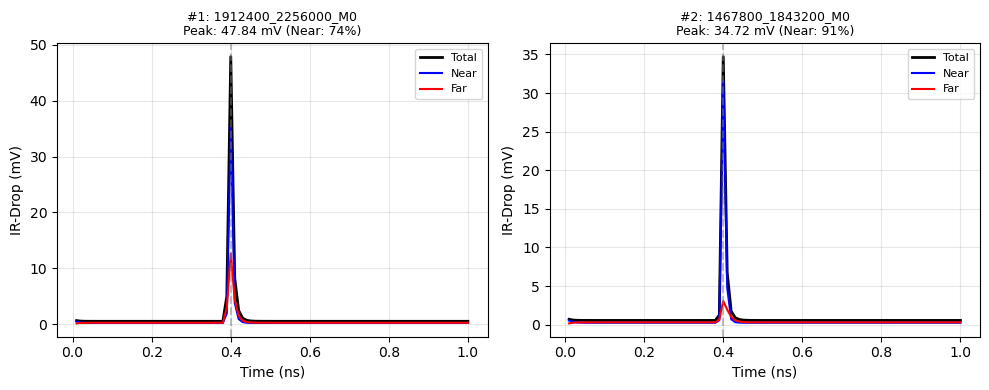

In [15]:
# Waveform plots: Total / Near / Far overlaid per victim
if waveform_decompositions:
    n_cols = min(3, len(waveform_decompositions))
    n_rows = (len(waveform_decompositions) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    for i, d in enumerate(waveform_decompositions):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]

        t_ns = d['t_array'] * 1e9
        ax.plot(t_ns, d['ir_drop_all'] * 1000, 'k-', linewidth=2, label='Total')
        ax.plot(t_ns, d['ir_drop_near'] * 1000, 'b-', linewidth=1.5, label='Near')
        ax.plot(t_ns, d['ir_drop_far'] * 1000, 'r-', linewidth=1.5, label='Far')

        # Mark peak time
        peak_idx = int(np.argmax(d['ir_drop_all']))
        if peak_idx < len(t_ns):
            ax.axvline(t_ns[peak_idx], color='gray', linestyle='--', alpha=0.5)

        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('IR-Drop (mV)')
        node_short = d['node'][:25] + '...' if len(d['node']) > 28 else d['node']
        ax.set_title(
            f'#{d["rank"]}: {node_short}\n'
            f'Peak: {d["peak_all_mV"]:.2f} mV '
            f'(Near: {d["near_pct_at_peak"]:.0f}%)',
            fontsize=9,
        )
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)

    # Hide empty subplots
    for i in range(len(waveform_decompositions), n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No waveform decompositions to plot.")

### Static vs Dynamic Adjoint: Interpretation

- **Static adjoint** uses the steady-state sensitivity matrix G^{-1}. It answers:
  *"If this source were always on, how much would it affect the victim?"*
  Fast (single solve) but ignores RC time constants.

- **Dynamic adjoint** propagates sensitivities backward through the RC network's
  memory window. It answers: *"Given the actual time-varying currents, which sources
  contributed most to the IR-drop at time T?"*

**When the results agree** (same top aggressors, similar contributions): the RC time
constants are small relative to the current switching -- the grid responds
quasi-statically.

**When results differ**: decoupling capacitance plays a significant role. Sources that
switch near time T may rank higher in the dynamic analysis, while DC-heavy sources
rank higher in static.

## Results Summary

In [16]:
print("=" * 80)
print("DISTRIBUTED DYNAMIC IR-DROP DECOMPOSITION ANALYSIS RESULTS")
print("=" * 80)
print(f"PKL dir: {PKL_DIR}")
print(f"Net: {model.net_name}")
print(f"Vdd: {model.vdd} V")
print(f"Tiles: {model.n_tiles} ({model.tile_grid[0]}x{model.tile_grid[1]})")
print(f"Method: transient ({INTEGRATION_METHOD.upper()})")
print(f"Time range: {T_START*1e9:.2f} ns - {T_END*1e9:.2f} ns (dt={DT*1e9:.2f} ns)")
print(f"Window size: {WINDOW_PERCENT:.1f}% of design")
print(f"Peak IR-drop: {trans_result.peak_ir_drop * 1000:.3f} mV")
print()

print(f"TOP-{len(near_far_results)} WORST INSTANCES WITH NEAR/FAR DECOMPOSITION")
print("=" * 80)
print(f"{'Rank':<5} {'Node':<25} {'Peak(mV)':<10} {'Near(mV)':<10} {'Far(mV)':<10} {'Near%':<7} {'Far%':<7}")
print("-" * 80)
for i, r in enumerate(near_far_results, 1):
    node_short = r['node'][:23] + '..' if len(r['node']) > 25 else r['node']
    print(f"{i:<5} {node_short:<25} {r['peak_mV']:<10.3f} {r['near_mV']:<10.3f} "
          f"{r['far_mV']:<10.3f} {r['near_pct']:<7.1f} {r['far_pct']:<7.1f}")

if near_far_results:
    avg_near = np.mean([r['near_pct'] for r in near_far_results])
    avg_far = np.mean([r['far_pct'] for r in near_far_results])
    print(f"\nAverage near contribution: {avg_near:.1f}%")
    print(f"Average far contribution: {avg_far:.1f}%")

print()
print(f"ADJOINT DECOMPOSITION (Top-{ADJOINT_TOP_K} aggressors per victim)")
print("=" * 80)

for i, comp in enumerate(adjoint_comparisons, 1):
    s = comp.static_result
    d = comp.dynamic_result
    s_nodes_set = {a.node for a in s.top_aggressors}
    d_nodes_set = {a.node for a in d.top_aggressors}
    overlap = len(s_nodes_set & d_nodes_set)

    print(f"\n  Victim #{i}: {comp.node[:50]}")
    print(f"  Location: ({comp.x:.0f}, {comp.y:.0f})  Peak: {comp.peak_drop_mV:.3f} mV")
    print(f"  Static:  IR-drop={s.ir_drop_at_T:.3f} mV, Self={s.self_contribution_mV:.3f} mV ({s.self_contribution_pct:.1f}%), eff={s.attribution_efficiency:.3f}")
    print(f"  Dynamic: IR-drop={d.ir_drop_at_T:.3f} mV, Self={d.self_contribution_mV:.3f} mV ({d.self_contribution_pct:.1f}%), eff={d.attribution_efficiency:.3f}")
    print(f"  Top-{ADJOINT_TOP_K} overlap: {overlap}/{ADJOINT_TOP_K}")

print()
print("Timing breakdown:")
for key, val in timings.items():
    print(f"  {key}: {val:.3f} s")
total = sum(v for v in timings.values() if isinstance(v, (int, float)))
print(f"  TOTAL: {total:.3f} s")

DISTRIBUTED DYNAMIC IR-DROP DECOMPOSITION ANALYSIS RESULTS
PKL dir: /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled/distributed_pkl
Net: VDD_XLV
Vdd: 0.66 V
Tiles: 9 (3x3)
Method: transient (BE)
Time range: 0.00 ns - 1.00 ns (dt=0.01 ns)
Window size: 10.0% of design
Peak IR-drop: 47.842 mV

TOP-2 WORST INSTANCES WITH NEAR/FAR DECOMPOSITION
Rank  Node                      Peak(mV)   Near(mV)   Far(mV)    Near%   Far%   
--------------------------------------------------------------------------------
1     1912400_2256000_M0        47.842     35.177     12.666     73.5    26.5   
2     1467800_1843200_M0        34.717     31.660     3.057      91.2    8.8    

Average near contribution: 82.4%
Average far contribution: 17.6%

ADJOINT DECOMPOSITION (Top-10 aggressors per victim)

  Victim #1: 1912400_2256000_M0
  Location: (1912400, 2256000)  Peak: 47.842 mV
  Static:  IR-drop=55.277 mV, Self=11.588 mV (21.0%), eff=1.000
  Dynamic: IR-drop=47.842 mV, Self=11.3

## Cleanup

Release factorizations and shut down Ray workers.

In [17]:
# Release factorization contexts
dc_ctx.release()
trans_ctx.release()

# Shut down Ray workers and backend
model.shutdown()

print("Contexts released, workers shut down.")

Contexts released, workers shut down.


## Interpretation Guide

### Adjoint Attribution Analysis

The adjoint sensitivity analysis identifies **individual aggressor contributions** to
a victim node's IR-drop. This is more precise than the near/far spatial decomposition
used in the flat solver, because:

- **Individual source resolution**: Each aggressor current source gets a quantified
  contribution in mV, rather than just an aggregate "near" vs "far" split.
- **Self-contribution**: The victim's own current draw is explicitly separated.
- **Attribution efficiency**: Values near 1.0 indicate the top-K aggressors explain
  most of the IR-drop; low values suggest many small distributed contributors.

### Key Metrics

- **IR-drop at T**: The actual voltage drop at the victim at the observation time
- **Self-contribution**: How much of the drop is caused by the victim's own switching
- **Attribution efficiency**: Fraction of total IR-drop explained by all identified sources
- **Top-K overlap**: Number of aggressors in common between static and dynamic methods;
  high overlap indicates quasi-static behavior (RC << switching period)

### When to Use Which Method

- **Static adjoint**: Good first approximation. Use when RC time constants are small
  relative to switching period, or for fast iterative design exploration.
- **Dynamic adjoint**: Use for final sign-off analysis, or when decoupling capacitance
  is significant (e.g., on-die decap, large package capacitors).
- **Agreement between methods**: When both methods produce similar top aggressors
  and contributions, the design's RC effects are negligible at the time scale of
  interest -- the grid responds quasi-statically to current changes.